# **FYP Sales Forecasting Model Building (Sales Amount)**

**Import Module**

All the import module will be written below

In [344]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import holidays
import joblib

### Model Training

Read Sales Forecasting Data

In [345]:
sales_forecast_data = pd.read_csv("Sales Forecasting Data New.csv")
sales_forecast_data

,order_purchase_timestamp,sales
0,2017-02-01,8788.70
1,2017-02-02,10334.07
2,2017-02-03,10797.08
3,2017-02-04,15320.15
4,2017-02-05,10035.21
...,...,...
570,2018-08-25,11737.76
571,2018-08-26,9333.16
572,2018-08-27,6111.61
573,2018-08-28,4121.22


In [346]:
sales_forecast_data['order_purchase_timestamp'] = pd.to_datetime(sales_forecast_data['order_purchase_timestamp'])

sales_forecast_data = sales_forecast_data.sort_values('order_purchase_timestamp')

sales_forecast_data = sales_forecast_data.set_index('order_purchase_timestamp')

full_date_range = pd.date_range(start=sales_forecast_data.index.min(), end=sales_forecast_data.index.max(), freq='D')
sales_forecast_data = sales_forecast_data.reindex(full_date_range, fill_value=0)
sales_forecast_data.index.name = 'order_purchase_timestamp'
sales_forecast_data

,sales
order_purchase_timestamp,
2017-02-01,8788.70
2017-02-02,10334.07
2017-02-03,10797.08
2017-02-04,15320.15
2017-02-05,10035.21
...,...
2018-08-25,11737.76
2018-08-26,9333.16
2018-08-27,6111.61


Feature Engineering

In [347]:
def create_features(df):

    df = df.copy()

    # A. Date Components
    df['day'] = df.index.day
    df['day_of_week'] = df.index.dayofweek
    df['month'] = df.index.month
    df['day_of_year'] = df.index.dayofyear
    df['is_month_start'] = df.index.is_month_start.astype(int)
    df['is_month_end'] = df.index.is_month_end.astype(int)

    br_holidays = holidays.BR()
    df['is_holiday'] = df.index.isin(br_holidays).astype(int)

    df['is_payday'] = (df.index.day.isin([5, 25])).astype(int)

    df['is_black_friday'] = (
        (df.index.month == 11) &
        (df.index.dayofweek == 4) &
        (df.index.day >= 22)
    ).astype(int)

    # B. Lag Features (Past values)
    df['lag_1'] = df['sales'].shift(1) 
    df['lag_7'] = df['sales'].shift(7) 
    df['lag_14'] = df['sales'].shift(14)
    df['lag_28'] = df['sales'].shift(28)

    # C. Rolling Window Features (Trends)  
    for window in [7, 28]:
        df[f'rolling_mean_{window}'] = df['sales'].shift(1).rolling(window=window).mean()

    df['ewm_7'] = df['sales'].shift(1).ewm(span=7, adjust=False).mean()
    df['ewm_28'] = df['sales'].shift(1).ewm(span=28, adjust=False).mean()

    df['pct_change_1d'] = df['sales'].shift(1).pct_change(1)
    df['pct_change_7d'] = df['sales'].shift(1).pct_change(7)

    df['diff_1d_lag'] = df['sales'].shift(1).diff(1)
    df['diff_7d_lag'] = df['sales'].shift(1).diff(7)

    def rolling_slope(series, window=7):
        slopes = []
        for i in range(len(series)):
            if i < window:
                slopes.append(np.nan)
            else:
                y = series.iloc[i-window:i].values
                x = np.arange(window)
                if len(y) > 1 and np.std(y) > 0:
                    slope = np.polyfit(x, y, 1)[0]
                    slopes.append(slope)
                else:
                    slopes.append(0)
        return pd.Series(slopes, index=series.index)

    df['trend_7d'] = rolling_slope(df['sales'].shift(1), window=7)
    df['trend_28d'] = rolling_slope(df['sales'].shift(1), window=28)
    
    return df


In [348]:
df_cleaned = create_features(sales_forecast_data)
df_cleaned = df_cleaned.dropna()

Data Splitting

In [349]:
# Split data (e.g., use data before 2018-06-01 for training)
split_date = '2018-06-01'

train = df_cleaned.loc[df_cleaned.index < split_date]
test = df_cleaned.loc[df_cleaned.index >= split_date]

print("Train set date range:")
print("Min:", train.index.min())
print("Max:", train.index.max())

print("\nTest set date range:")
print("Min:", test.index.min())
print("Max:", test.index.max())

Train set date range:
Min: 2017-03-01 00:00:00
Max: 2018-05-31 00:00:00

Test set date range:
Min: 2018-06-01 00:00:00
Max: 2018-08-29 00:00:00


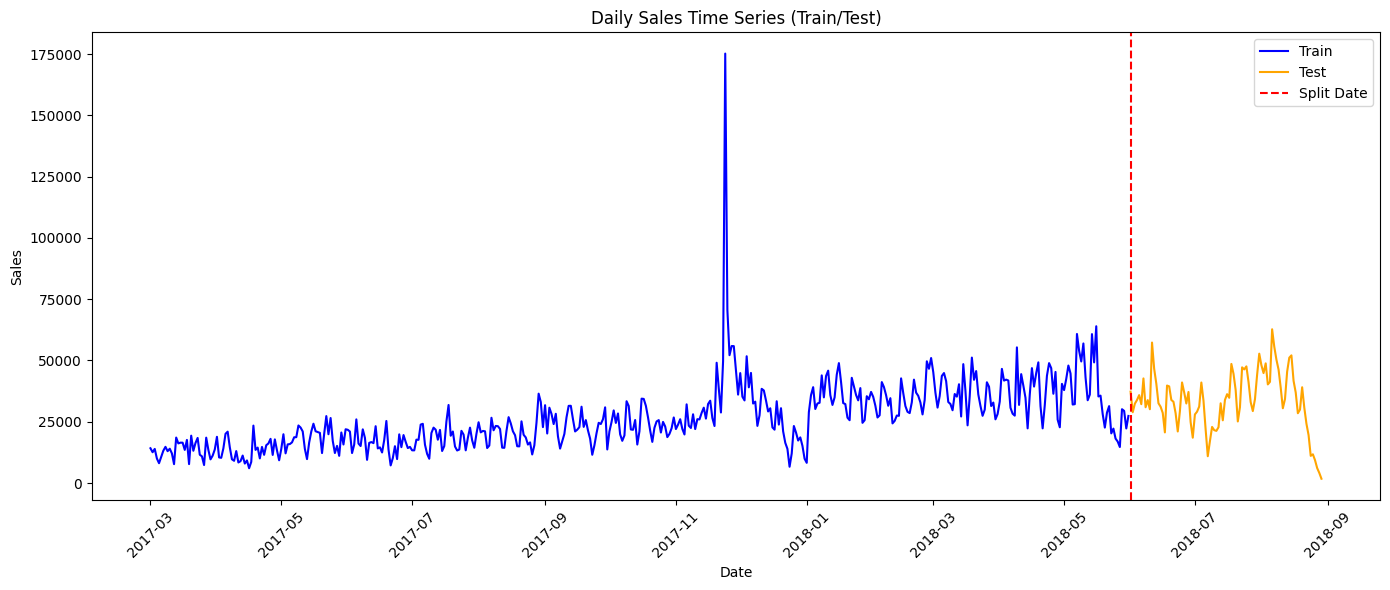

In [350]:
plt.figure(figsize=(14,6))
plt.plot(train.index, train['sales'], label='Train', color='blue')
plt.plot(test.index, test['sales'], label='Test', color='orange')

plt.axvline(pd.to_datetime(split_date), color='red', linestyle='--', label='Split Date')

plt.title('Daily Sales Time Series (Train/Test)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Prepare X & Y train test

In [351]:
features = ['day','day_of_week', 'month', 'day_of_year', 'is_month_start','is_month_end','is_payday','is_holiday' ,'is_black_friday',
            'lag_1', 'lag_7', 'lag_14', 'lag_28' ,'rolling_mean_7', 'rolling_mean_28', 'ewm_7', 'ewm_28',
            'pct_change_1d', 'pct_change_7d', 'diff_1d_lag', 'diff_7d_lag', 'trend_7d', 'trend_28d']
target = 'sales'

X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

**Linear Regression**

In [352]:
model = LinearRegression(n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Model Evaluation (Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), Mean Absolute Percentage Error (MAPE), and R-squared (R2))

Linear Regression Evaluation Metrics:
+---------------------------------------+-------------+
| Metric                                |       Score |
+=======================================+=============+
| Mean Absolute Error (MAE)             | 5884.59     |
+---------------------------------------+-------------+
| Root Mean Squared Error (RMSE)        | 7374.67     |
+---------------------------------------+-------------+
| Mean Absolute Percentage Error (MAPE) |   34.7114   |
+---------------------------------------+-------------+
| R² Score                              |    0.620322 |
+---------------------------------------+-------------+


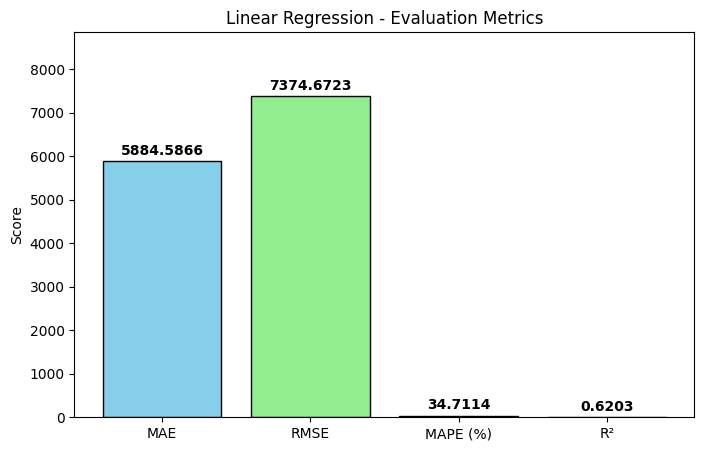

In [353]:
lr_mae = mean_absolute_error(y_test, y_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
lr_mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
lr_r2 = r2_score(y_test, y_pred)

# Prepare table for tabulate
eval_table = [
    ["Metric", "Score"],
    ["Mean Absolute Error (MAE)", lr_mae],
    ["Root Mean Squared Error (RMSE)", lr_rmse],
    ["Mean Absolute Percentage Error (MAPE)", lr_mape],
    ["R² Score", lr_r2]
]

print("Linear Regression Evaluation Metrics:")
print(tabulate(eval_table, headers="firstrow", tablefmt="grid"))

# Plot the metrics
metrics = ["MAE", "RMSE", "MAPE (%)", "R²"]
scores = [lr_mae, lr_rmse, lr_mape, lr_r2]
colors = ['skyblue', 'lightgreen', 'salmon', 'orange']

plt.figure(figsize=(8,5))
bars = plt.bar(metrics, scores, color=colors, edgecolor='black')
plt.title("Linear Regression - Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0, max(scores)*1.2)  # Add some space for labels

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + max(scores)*0.02, 
             f"{height:.4f}", ha='center', fontweight='bold')

plt.show()

**Random Forest**

In [354]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

Model Evaluation (Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), Mean Absolute Percentage Error (MAPE), and R-squared (R2))

Random Forest Evaluation Metrics:
+---------------------------------------+-------------+
| Metric                                |       Score |
+=======================================+=============+
| Mean Absolute Error (MAE)             | 5384.61     |
+---------------------------------------+-------------+
| Root Mean Squared Error (RMSE)        | 7057.12     |
+---------------------------------------+-------------+
| Mean Absolute Percentage Error (MAPE) |   34.2965   |
+---------------------------------------+-------------+
| R² Score                              |    0.652316 |
+---------------------------------------+-------------+


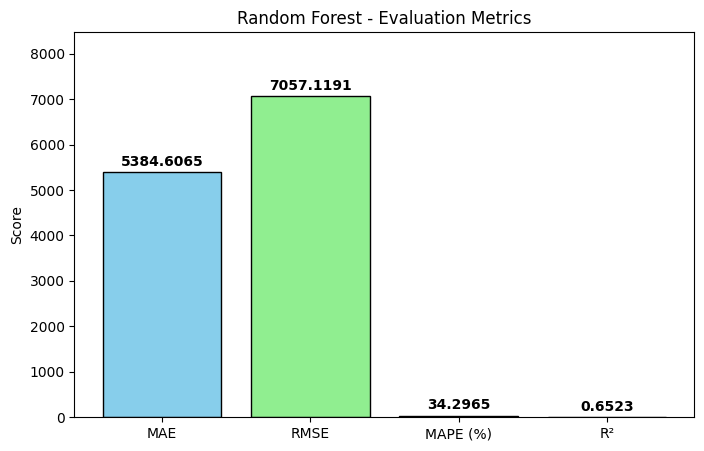

In [355]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mape = np.mean(np.abs((y_test - rf_pred) / y_test)) * 100
rf_r2 = r2_score(y_test, rf_pred)

# Prepare table for tabulate
eval_table = [
    ["Metric", "Score"],
    ["Mean Absolute Error (MAE)", rf_mae],
    ["Root Mean Squared Error (RMSE)", rf_rmse],
    ["Mean Absolute Percentage Error (MAPE)", rf_mape],
    ["R² Score", rf_r2]
]

print("Random Forest Evaluation Metrics:")
print(tabulate(eval_table, headers="firstrow", tablefmt="grid"))

# Plot all metrics
metrics = ["MAE", "RMSE", "MAPE (%)", "R²"]
scores = [rf_mae, rf_rmse, rf_mape, rf_r2]
colors = ['skyblue', 'lightgreen', 'salmon', 'orange']

plt.figure(figsize=(8,5))
bars = plt.bar(metrics, scores, color=colors, edgecolor='black')
plt.title("Random Forest - Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0, max(scores)*1.2)  # Add some space for labels

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + max(scores)*0.02, 
             f"{height:.4f}", ha='center', fontweight='bold')

plt.show()

**XGBoost**

In [356]:
reg_xgb = xgb.XGBRegressor(n_estimators=1000, early_stopping_rounds=50,objective='reg:squarederror', random_state=42)
reg_xgb.fit(X_train, y_train,
            eval_set=[(X_train, y_train), (X_test, y_test)],
            verbose=100)

xgb_pred = reg_xgb.predict(X_test)

[0]	validation_0-rmse:10624.16334	validation_1-rmse:11573.41422
[88]	validation_0-rmse:29.83758	validation_1-rmse:6807.96853


Model Evaluation (Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), Mean Absolute Percentage Error (MAPE), and R-squared (R2))

XGBoost Evaluation Metrics:
+---------------------------------------+-------------+
| Metric                                |       Score |
+=======================================+=============+
| Mean Absolute Error (MAE)             | 5350.24     |
+---------------------------------------+-------------+
| Root Mean Squared Error (RMSE)        | 6740.11     |
+---------------------------------------+-------------+
| Mean Absolute Percentage Error (MAPE) |   32.843    |
+---------------------------------------+-------------+
| R² Score                              |    0.682851 |
+---------------------------------------+-------------+


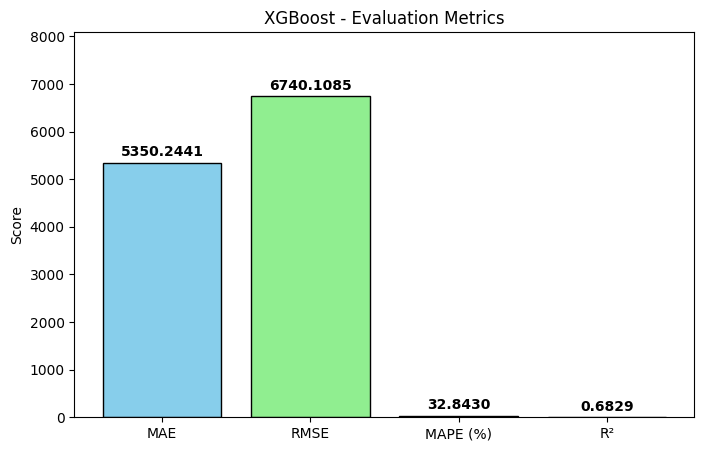

In [357]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mape = np.mean(np.abs((y_test - xgb_pred) / y_test)) * 100
xgb_r2 = r2_score(y_test, xgb_pred)

# Prepare table for tabulate
eval_table = [
    ["Metric", "Score"],
    ["Mean Absolute Error (MAE)", xgb_mae],
    ["Root Mean Squared Error (RMSE)", xgb_rmse],
    ["Mean Absolute Percentage Error (MAPE)", xgb_mape],
    ["R² Score", xgb_r2]
]

print("XGBoost Evaluation Metrics:")
print(tabulate(eval_table, headers="firstrow", tablefmt="grid"))

# Plot all metrics
metrics = ["MAE", "RMSE", "MAPE (%)", "R²"]
scores = [xgb_mae, xgb_rmse, xgb_mape, xgb_r2]
colors = ['skyblue', 'lightgreen', 'salmon', 'orange']

plt.figure(figsize=(8,5))
bars = plt.bar(metrics, scores, color=colors, edgecolor='black')
plt.title("XGBoost - Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0, max(scores)*1.2)  # Add some space for labels

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + max(scores)*0.02, 
             f"{height:.4f}", ha='center', fontweight='bold')

plt.show()

**LightGBM**

In [358]:
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'random_state': 42,
    'verbose': -1,
    'n_jobs': -1,
    'feature_pre_filter': False
}

lgbm_model = lgb.train(params, train_data, num_boost_round=1000, 
                       valid_sets=[test_data],
                       callbacks=[lgb.early_stopping(stopping_rounds=50)])

lgbm_pred = lgbm_model.predict(X_test)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[84]	valid_0's rmse: 7001.43


LightGBM Evaluation Metrics:
+---------------------------------------+-------------+
| Metric                                |       Score |
+=======================================+=============+
| Mean Absolute Error (MAE)             | 5143.21     |
+---------------------------------------+-------------+
| Root Mean Squared Error (RMSE)        | 7001.43     |
+---------------------------------------+-------------+
| Mean Absolute Percentage Error (MAPE) |   29.533    |
+---------------------------------------+-------------+
| R² Score                              |    0.657782 |
+---------------------------------------+-------------+


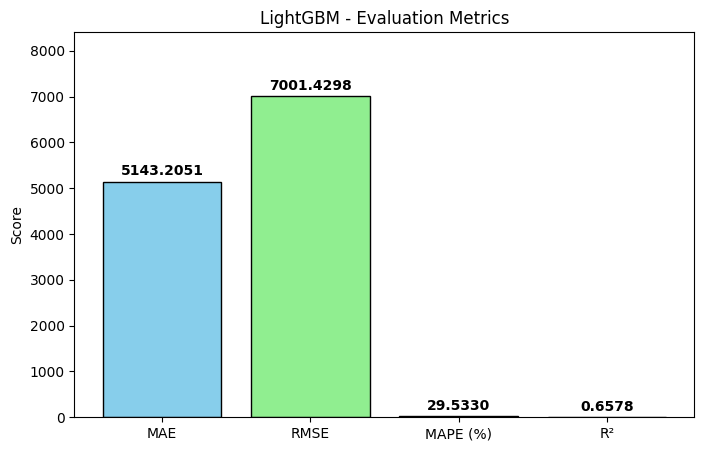

In [359]:
lgbm_mae = mean_absolute_error(y_test, lgbm_pred)
lgbm_rmse = np.sqrt(mean_squared_error(y_test, lgbm_pred))
lgbm_mape = np.mean(np.abs((y_test - lgbm_pred) / y_test)) * 100
lgbm_r2 = r2_score(y_test, lgbm_pred)

# Prepare table for tabulate
eval_table = [
    ["Metric", "Score"],
    ["Mean Absolute Error (MAE)", lgbm_mae],
    ["Root Mean Squared Error (RMSE)", lgbm_rmse],
    ["Mean Absolute Percentage Error (MAPE)", lgbm_mape],
    ["R² Score", lgbm_r2]
]

print("LightGBM Evaluation Metrics:")
print(tabulate(eval_table, headers="firstrow", tablefmt="grid"))

# Plot all metrics
metrics = ["MAE", "RMSE", "MAPE (%)", "R²"]
scores = [lgbm_mae, lgbm_rmse, lgbm_mape, lgbm_r2]
colors = ['skyblue', 'lightgreen', 'salmon', 'orange']

plt.figure(figsize=(8,5))
bars = plt.bar(metrics, scores, color=colors, edgecolor='black')
plt.title("LightGBM - Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0, max(scores)*1.2)  # Add some space for labels

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + max(scores)*0.02, 
             f"{height:.4f}", ha='center', fontweight='bold')

plt.show()

### Hyperparameter Tuning

**Time Series Split**

In [360]:
tscv = TimeSeriesSplit(n_splits=5)

**Linear Regression**

In [361]:
lr_grid = {
    'copy_X': [True, False],
    'fit_intercept': [True, False],
    'n_jobs': [-1, 1, 5, 10, 15, None],
    'positive': [True, False]
}

lr_search = RandomizedSearchCV(
    estimator=LinearRegression(),
    param_distributions=lr_grid,
    n_iter=100,                
    scoring='neg_root_mean_squared_error',             
    cv=tscv,
    random_state=42,                     
    n_jobs=-1,
    verbose=1                
)

lr_search.fit(X_train, y_train)

print("Best parameters:", lr_search.best_params_)
print("Best CV F1-score:", lr_search.best_score_)

c:\laragon\www\fyp-model-building\venv\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 48 is smaller than n_iter=100. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best parameters: {'positive': True, 'n_jobs': -1, 'fit_intercept': True, 'copy_X': True}
Best CV F1-score: -10122.801279406758


Tuned Linear Regression Evaluation Metrics:
+---------------------------------------+-------------+
| Metric                                |       Score |
+=======================================+=============+
| Mean Absolute Error (MAE)             | 6329.5      |
+---------------------------------------+-------------+
| Root Mean Squared Error (RMSE)        | 8018.56     |
+---------------------------------------+-------------+
| Mean Absolute Percentage Error (MAPE) |   36.9737   |
+---------------------------------------+-------------+
| R² Score                              |    0.551128 |
+---------------------------------------+-------------+


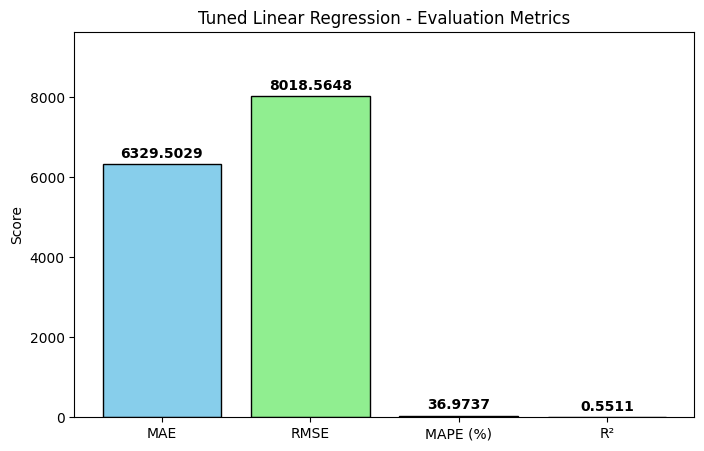

In [362]:
best_lr_model = lr_search.best_estimator_
best_lr_y_pred = best_lr_model.predict(X_test)

best_lr_mae = mean_absolute_error(y_test, best_lr_y_pred)
best_lr_rmse = np.sqrt(mean_squared_error(y_test, best_lr_y_pred))
best_lr_mape = np.mean(np.abs((y_test - best_lr_y_pred) / y_test)) * 100
best_lr_r2 = r2_score(y_test, best_lr_y_pred)

# Prepare table for tabulate
eval_table = [
    ["Metric", "Score"],
    ["Mean Absolute Error (MAE)", best_lr_mae],
    ["Root Mean Squared Error (RMSE)", best_lr_rmse],
    ["Mean Absolute Percentage Error (MAPE)", best_lr_mape],
    ["R² Score", best_lr_r2]
]

print("Tuned Linear Regression Evaluation Metrics:")
print(tabulate(eval_table, headers="firstrow", tablefmt="grid"))

# Plot all metrics
metrics = ["MAE", "RMSE", "MAPE (%)", "R²"]
scores = [best_lr_mae, best_lr_rmse, best_lr_mape, best_lr_r2]
colors = ['skyblue', 'lightgreen', 'salmon', 'orange']

plt.figure(figsize=(8,5))
bars = plt.bar(metrics, scores, color=colors, edgecolor='black')
plt.title("Tuned Linear Regression - Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0, max(scores)*1.2)  # Add some space for labels

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + max(scores)*0.02, 
             f"{height:.4f}", ha='center', fontweight='bold')

plt.show()

Performance Comparison

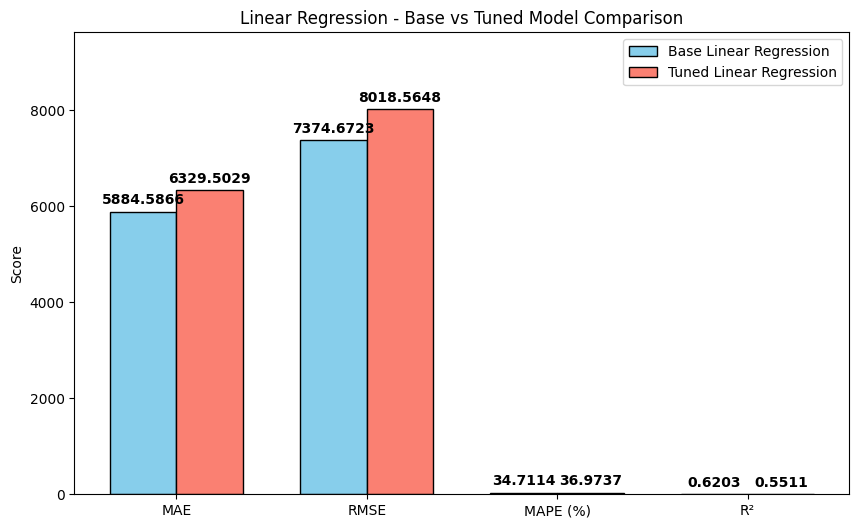

In [363]:
metrics = ["MAE", "RMSE", "MAPE (%)", "R²"]
base_scores = [lr_mae, lr_rmse, lr_mape, lr_r2]
tuned_scores = [best_lr_mae, best_lr_rmse, best_lr_mape, best_lr_r2]

x = np.arange(len(metrics))  # positions for groups
width = 0.35  # width of each bar

plt.figure(figsize=(10,6))

# Plot bars
bars1 = plt.bar(x - width/2, base_scores, width, label='Base Linear Regression', color='skyblue', edgecolor='black')
bars2 = plt.bar(x + width/2, tuned_scores, width, label='Tuned Linear Regression', color='salmon', edgecolor='black')

# Labels and title
plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Linear Regression - Base vs Tuned Model Comparison")
plt.ylim(0, max(max(base_scores), max(tuned_scores)) * 1.2)  # add space for labels
plt.legend()

# Add values on top
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02*max(max(base_scores), max(tuned_scores)),
             f"{height:.4f}", ha='center', fontweight='bold')
for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02*max(max(base_scores), max(tuned_scores)),
             f"{height:.4f}", ha='center', fontweight='bold')

plt.show()

**Random Forest**

In [364]:
rf_grid = {
    'n_estimators': [100, 200, 300],  
    'max_depth': [5, 10, 15, None],  
    'min_samples_split': [2, 5, 10],  
    'min_samples_leaf': [1, 2, 4],    
    'max_features': ['sqrt', 'log2', 0.5, 1.0]  
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=rf_grid,
    n_iter=100, 
    cv=tscv,  
    scoring='neg_root_mean_squared_error',
    random_state=42, 
    n_jobs=-1, 
    verbose=1
)

# 3. Fit
print("Tuning Random Forest...")
rf_search.fit(X_train, y_train)

print(f"Best RF Params: {rf_search.best_params_}")
print(f"Best RF Score (Negative RMSE): {rf_search.best_score_}")

Tuning Random Forest...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best RF Params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': 5}
Best RF Score (Negative RMSE): -9373.968492079493


Model Evaluation (Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), Mean Absolute Percentage Error (MAPE), and R-squared (R2))

Tuned Random Forest Evaluation Metrics:
+---------------------------------------+-------------+
| Metric                                |       Score |
+=======================================+=============+
| Mean Absolute Error (MAE)             | 5364.74     |
+---------------------------------------+-------------+
| Root Mean Squared Error (RMSE)        | 7046.54     |
+---------------------------------------+-------------+
| Mean Absolute Percentage Error (MAPE) |   34.3288   |
+---------------------------------------+-------------+
| R² Score                              |    0.653357 |
+---------------------------------------+-------------+


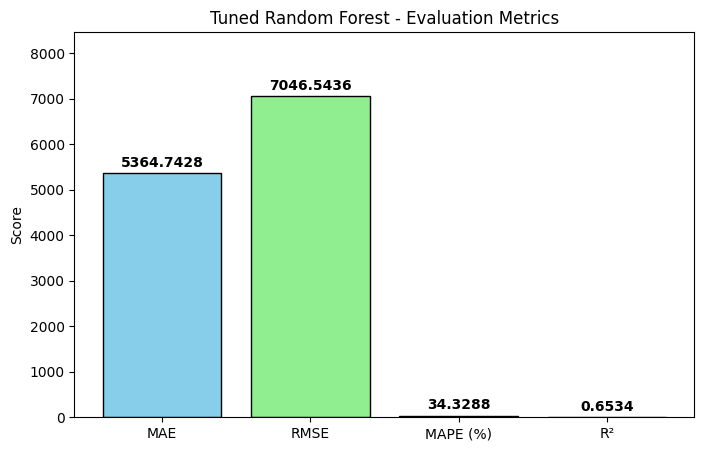

In [365]:
best_rf_model = rf_search.best_estimator_
best_rf_y_pred = best_rf_model.predict(X_test)

best_rf_mae = mean_absolute_error(y_test, best_rf_y_pred)
best_rf_rmse = np.sqrt(mean_squared_error(y_test, best_rf_y_pred))
best_rf_mape = np.mean(np.abs((y_test - best_rf_y_pred) / y_test)) * 100
best_rf_r2 = r2_score(y_test, best_rf_y_pred)

# Prepare table for tabulate
eval_table = [
    ["Metric", "Score"],
    ["Mean Absolute Error (MAE)", best_rf_mae],
    ["Root Mean Squared Error (RMSE)", best_rf_rmse],
    ["Mean Absolute Percentage Error (MAPE)", best_rf_mape],
    ["R² Score", best_rf_r2]
]

print("Tuned Random Forest Evaluation Metrics:")
print(tabulate(eval_table, headers="firstrow", tablefmt="grid"))

# Plot all metrics
metrics = ["MAE", "RMSE", "MAPE (%)", "R²"]
scores = [best_rf_mae, best_rf_rmse, best_rf_mape, best_rf_r2]
colors = ['skyblue', 'lightgreen', 'salmon', 'orange']

plt.figure(figsize=(8,5))
bars = plt.bar(metrics, scores, color=colors, edgecolor='black')
plt.title("Tuned Random Forest - Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0, max(scores)*1.2)  # Add some space for labels

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + max(scores)*0.02, 
             f"{height:.4f}", ha='center', fontweight='bold')

plt.show()

Performance Comparison

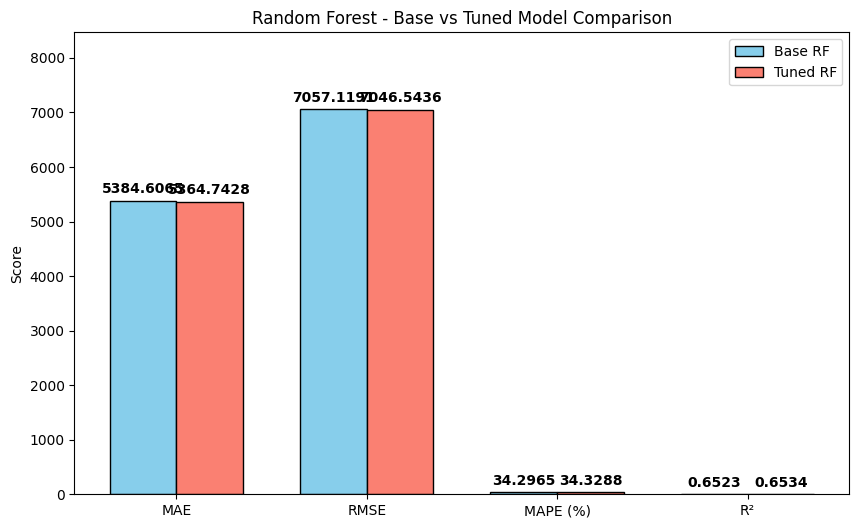

In [366]:
metrics = ["MAE", "RMSE", "MAPE (%)", "R²"]
base_scores = [rf_mae, rf_rmse, rf_mape, rf_r2]
tuned_scores = [best_rf_mae, best_rf_rmse, best_rf_mape, best_rf_r2]

x = np.arange(len(metrics))  # positions for groups
width = 0.35  # width of each bar

plt.figure(figsize=(10,6))

# Plot bars
bars1 = plt.bar(x - width/2, base_scores, width, label='Base RF', color='skyblue', edgecolor='black')
bars2 = plt.bar(x + width/2, tuned_scores, width, label='Tuned RF', color='salmon', edgecolor='black')

# Labels and title
plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Random Forest - Base vs Tuned Model Comparison")
plt.ylim(0, max(max(base_scores), max(tuned_scores))*1.2)  # extra space for labels
plt.legend()

# Add values on top
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02*max(max(base_scores), max(tuned_scores)),
             f"{height:.4f}", ha='center', fontweight='bold')
for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02*max(max(base_scores), max(tuned_scores)),
             f"{height:.4f}", ha='center', fontweight='bold')

plt.show()

**XGBoost**

In [367]:
xgb_grid = {
    'n_estimators': [500, 1000, 1500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'reg_lambda': [0.1, 1.0, 10.0],
    'reg_alpha': [0.0, 0.1, 1.0]
}

# 2. Setup Search
xgb_search = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
    param_distributions=xgb_grid,
    n_iter=100,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# 3. Fit
print("Tuning XGBoost...")
xgb_search.fit(X_train, y_train)

print(f"Best XGB Params: {xgb_search.best_params_}")
print(f"Best XGB Score (Negative RMSE): {xgb_search.best_score_}")

Tuning XGBoost...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best XGB Params: {'subsample': 0.7, 'reg_lambda': 0.1, 'reg_alpha': 0.1, 'n_estimators': 1000, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Best XGB Score (Negative RMSE): -9636.248421940272


Train With Best Parameter

In [368]:
best_params = xgb_search.best_params_
final_model = xgb.XGBRegressor(
    **best_params,
    early_stopping_rounds=50,
    objective='reg:squarederror'
)

final_model.fit(X_train, y_train,
            eval_set=[(X_train, y_train), (X_test, y_test)],
            verbose=100)

best_xgb_y_pred = reg_xgb.predict(X_test)

[0]	validation_0-rmse:13399.80782	validation_1-rmse:14006.12833


[100]	validation_0-rmse:7083.47771	validation_1-rmse:8704.29526
[200]	validation_0-rmse:4852.17593	validation_1-rmse:7119.15568
[300]	validation_0-rmse:3969.81027	validation_1-rmse:6693.14733
[400]	validation_0-rmse:3512.28624	validation_1-rmse:6541.56945
[500]	validation_0-rmse:3167.80074	validation_1-rmse:6419.15758
[600]	validation_0-rmse:2873.06079	validation_1-rmse:6366.57547
[700]	validation_0-rmse:2593.82456	validation_1-rmse:6332.92989
[800]	validation_0-rmse:2358.08543	validation_1-rmse:6326.09951
[804]	validation_0-rmse:2350.70392	validation_1-rmse:6323.57007


Model Evaluation (Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), Mean Absolute Percentage Error (MAPE), and R-squared (R2))

Tuned XGBoost Evaluation Metrics:
+---------------------------------------+-------------+
| Metric                                |       Score |
+=======================================+=============+
| Mean Absolute Error (MAE)             | 5350.24     |
+---------------------------------------+-------------+
| Root Mean Squared Error (RMSE)        | 6740.11     |
+---------------------------------------+-------------+
| Mean Absolute Percentage Error (MAPE) |   32.843    |
+---------------------------------------+-------------+
| R² Score                              |    0.682851 |
+---------------------------------------+-------------+


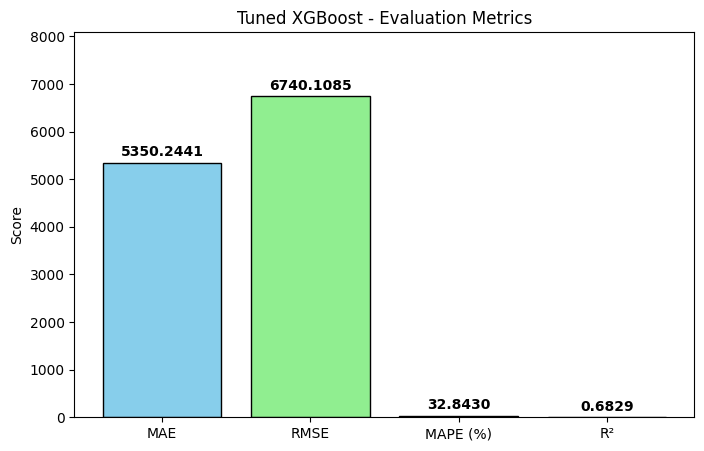

In [375]:
best_xgb_mae = mean_absolute_error(y_test, best_xgb_y_pred)
best_xgb_rmse = np.sqrt(mean_squared_error(y_test, best_xgb_y_pred))
best_xgb_mape = np.mean(np.abs((y_test - best_xgb_y_pred) / y_test)) * 100
best_xgb_r2 = r2_score(y_test, best_xgb_y_pred)

# Prepare table for tabulate
eval_table = [
    ["Metric", "Score"],
    ["Mean Absolute Error (MAE)", best_xgb_mae],
    ["Root Mean Squared Error (RMSE)", best_xgb_rmse],
    ["Mean Absolute Percentage Error (MAPE)", best_xgb_mape],
    ["R² Score", best_xgb_r2]
]

print("Tuned XGBoost Evaluation Metrics:")
print(tabulate(eval_table, headers="firstrow", tablefmt="grid"))

# Plot all metrics
metrics = ["MAE", "RMSE", "MAPE (%)", "R²"]
scores = [best_xgb_mae, best_xgb_rmse, best_xgb_mape, best_xgb_r2]
colors = ['skyblue', 'lightgreen', 'salmon', 'orange']

plt.figure(figsize=(8,5))
bars = plt.bar(metrics, scores, color=colors, edgecolor='black')
plt.title("Tuned XGBoost - Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0, max(scores)*1.2)  # Add some space for labels

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + max(scores)*0.02, 
             f"{height:.4f}", ha='center', fontweight='bold')

plt.show()

Performance Comparison

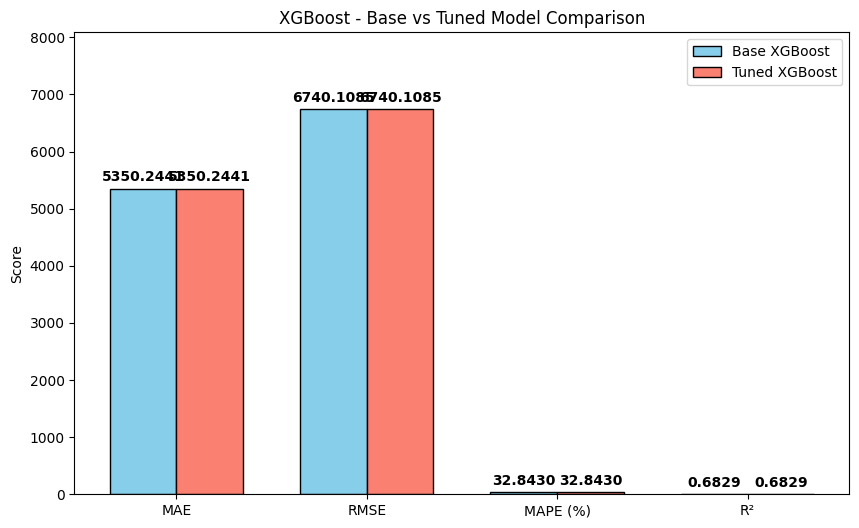

In [376]:
metrics = ["MAE", "RMSE", "MAPE (%)", "R²"]
base_scores = [xgb_mae, xgb_rmse, xgb_mape, xgb_r2]
tuned_scores = [best_xgb_mae, best_xgb_rmse, best_xgb_mape, best_xgb_r2]

x = np.arange(len(metrics))  # positions for groups
width = 0.35  # width of each bar

plt.figure(figsize=(10,6))

# Plot bars
bars1 = plt.bar(x - width/2, base_scores, width, label='Base XGBoost', color='skyblue', edgecolor='black')
bars2 = plt.bar(x + width/2, tuned_scores, width, label='Tuned XGBoost', color='salmon', edgecolor='black')

# Labels and title
plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("XGBoost - Base vs Tuned Model Comparison")
plt.ylim(0, max(max(base_scores), max(tuned_scores)) * 1.2)  # extra space for labels
plt.legend()

# Add values on top
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02*max(max(base_scores), max(tuned_scores)),
             f"{height:.4f}", ha='center', fontweight='bold')
for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02*max(max(base_scores), max(tuned_scores)),
             f"{height:.4f}", ha='center', fontweight='bold')

plt.show()

**LightGBM**

In [378]:
static_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'random_state': 42,
    'verbose': -1,
    'n_jobs': -1,
    'feature_pre_filter': False,
}

lgb_grid = {
    'n_estimators': [500, 1000, 1500],
    'num_leaves': [15, 31, 63],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_child_samples': [5, 10, 20],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_alpha': [0.0, 0.1],
    'reg_lambda': [1.0, 10.0]
}

# 2. Setup Search
lgb_search = RandomizedSearchCV(
    estimator=lgb.LGBMRegressor(**static_params),
    param_distributions=lgb_grid,
    n_iter=100,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# 3. Fit
print("Tuning LightGBM...")
lgb_search.fit(X_train, y_train)

print(f"Best LightGBM Params: {lgb_search.best_params_}")
print(f"Best LightGBM Score (Negative RMSE): {lgb_search.best_score_}")

Tuning LightGBM...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best LightGBM Params: {'subsample': 0.9, 'reg_lambda': 10.0, 'reg_alpha': 0.0, 'num_leaves': 15, 'n_estimators': 500, 'min_child_samples': 10, 'max_depth': 8, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Best LightGBM Score (Negative RMSE): -10050.008441585534


Train With Best Parameter

In [379]:
tuned_params = lgb_search.best_params_
final_params = {**static_params, **tuned_params}

train_data = lgb.Dataset(X_train, label=y_train, params=final_params)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data, params=final_params)

num_rounds = final_params.pop('n_estimators', 500)

final_lgbm_model = lgb.train(final_params, train_data, num_boost_round=num_rounds, 
                       valid_sets=[test_data],
                       callbacks=[lgb.early_stopping(stopping_rounds=50)])

best_lgbm_y_pred = final_lgbm_model.predict(X_test)

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[470]	valid_0's rmse: 6954.19


Model Evaluation (Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), Mean Absolute Percentage Error (MAPE), and R-squared (R2))

Tuned LightGBM Evaluation Metrics:
+---------------------------------------+-------------+
| Metric                                |       Score |
+=======================================+=============+
| Mean Absolute Error (MAE)             | 5399.73     |
+---------------------------------------+-------------+
| Root Mean Squared Error (RMSE)        | 6954.19     |
+---------------------------------------+-------------+
| Mean Absolute Percentage Error (MAPE) |   32.6725   |
+---------------------------------------+-------------+
| R² Score                              |    0.662385 |
+---------------------------------------+-------------+


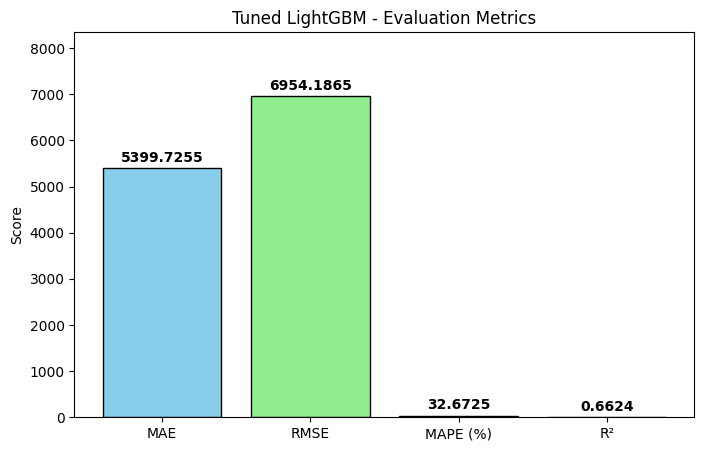

In [380]:
best_lgbm_mae = mean_absolute_error(y_test, best_lgbm_y_pred)
best_lgbm_rmse = np.sqrt(mean_squared_error(y_test, best_lgbm_y_pred))
best_lgbm_mape = np.mean(np.abs((y_test - best_lgbm_y_pred) / y_test)) * 100
best_lgbm_r2 = r2_score(y_test, best_lgbm_y_pred)

# Prepare table for tabulate
eval_table = [
    ["Metric", "Score"],
    ["Mean Absolute Error (MAE)", best_lgbm_mae],
    ["Root Mean Squared Error (RMSE)", best_lgbm_rmse],
    ["Mean Absolute Percentage Error (MAPE)", best_lgbm_mape],
    ["R² Score", best_lgbm_r2]
]

print("Tuned LightGBM Evaluation Metrics:")
print(tabulate(eval_table, headers="firstrow", tablefmt="grid"))

# Plot the metrics
metrics = ["MAE", "RMSE", "MAPE (%)", "R²"]
scores = [best_lgbm_mae, best_lgbm_rmse, best_lgbm_mape, best_lgbm_r2]
colors = ['skyblue', 'lightgreen', 'salmon', 'orange']

plt.figure(figsize=(8,5))
bars = plt.bar(metrics, scores, color=colors, edgecolor='black')
plt.title("Tuned LightGBM - Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0, max(scores)*1.2)  # Add some space for labels

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + max(scores)*0.02, 
             f"{height:.4f}", ha='center', fontweight='bold')

plt.show()

Performance Comparison

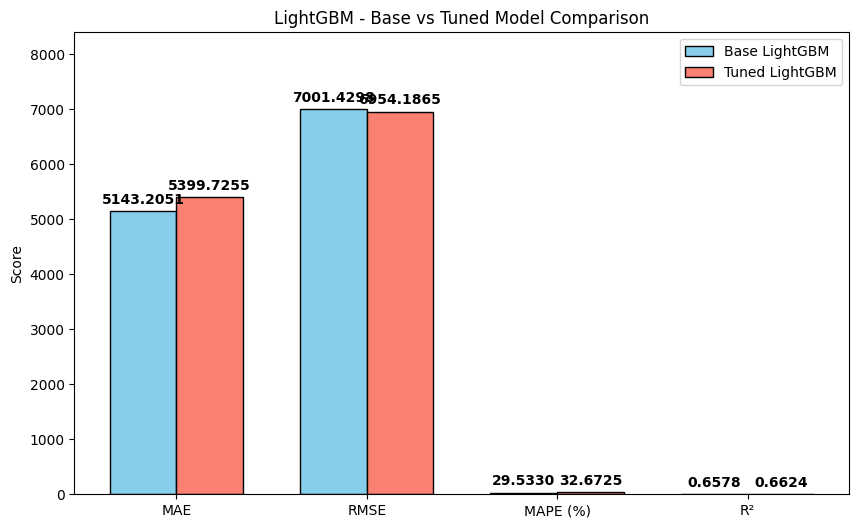

In [381]:
metrics = ["MAE", "RMSE", "MAPE (%)", "R²"]
base_scores = [lgbm_mae, lgbm_rmse, lgbm_mape, lgbm_r2]
tuned_scores = [best_lgbm_mae, best_lgbm_rmse, best_lgbm_mape, best_lgbm_r2]

x = np.arange(len(metrics))  # positions for groups
width = 0.35  # width of each bar

plt.figure(figsize=(10,6))

# Plot bars
bars1 = plt.bar(x - width/2, base_scores, width, label='Base LightGBM', color='skyblue', edgecolor='black')
bars2 = plt.bar(x + width/2, tuned_scores, width, label='Tuned LightGBM', color='salmon', edgecolor='black')

# Labels and title
plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("LightGBM - Base vs Tuned Model Comparison")
plt.ylim(0, max(max(base_scores), max(tuned_scores)) * 1.2)  # extra space for labels
plt.legend()

# Add values on top
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02*max(max(base_scores), max(tuned_scores)),
             f"{height:.4f}", ha='center', fontweight='bold')
for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02*max(max(base_scores), max(tuned_scores)),
             f"{height:.4f}", ha='center', fontweight='bold')

plt.show()

**Best Model Performance Comparison Chart**

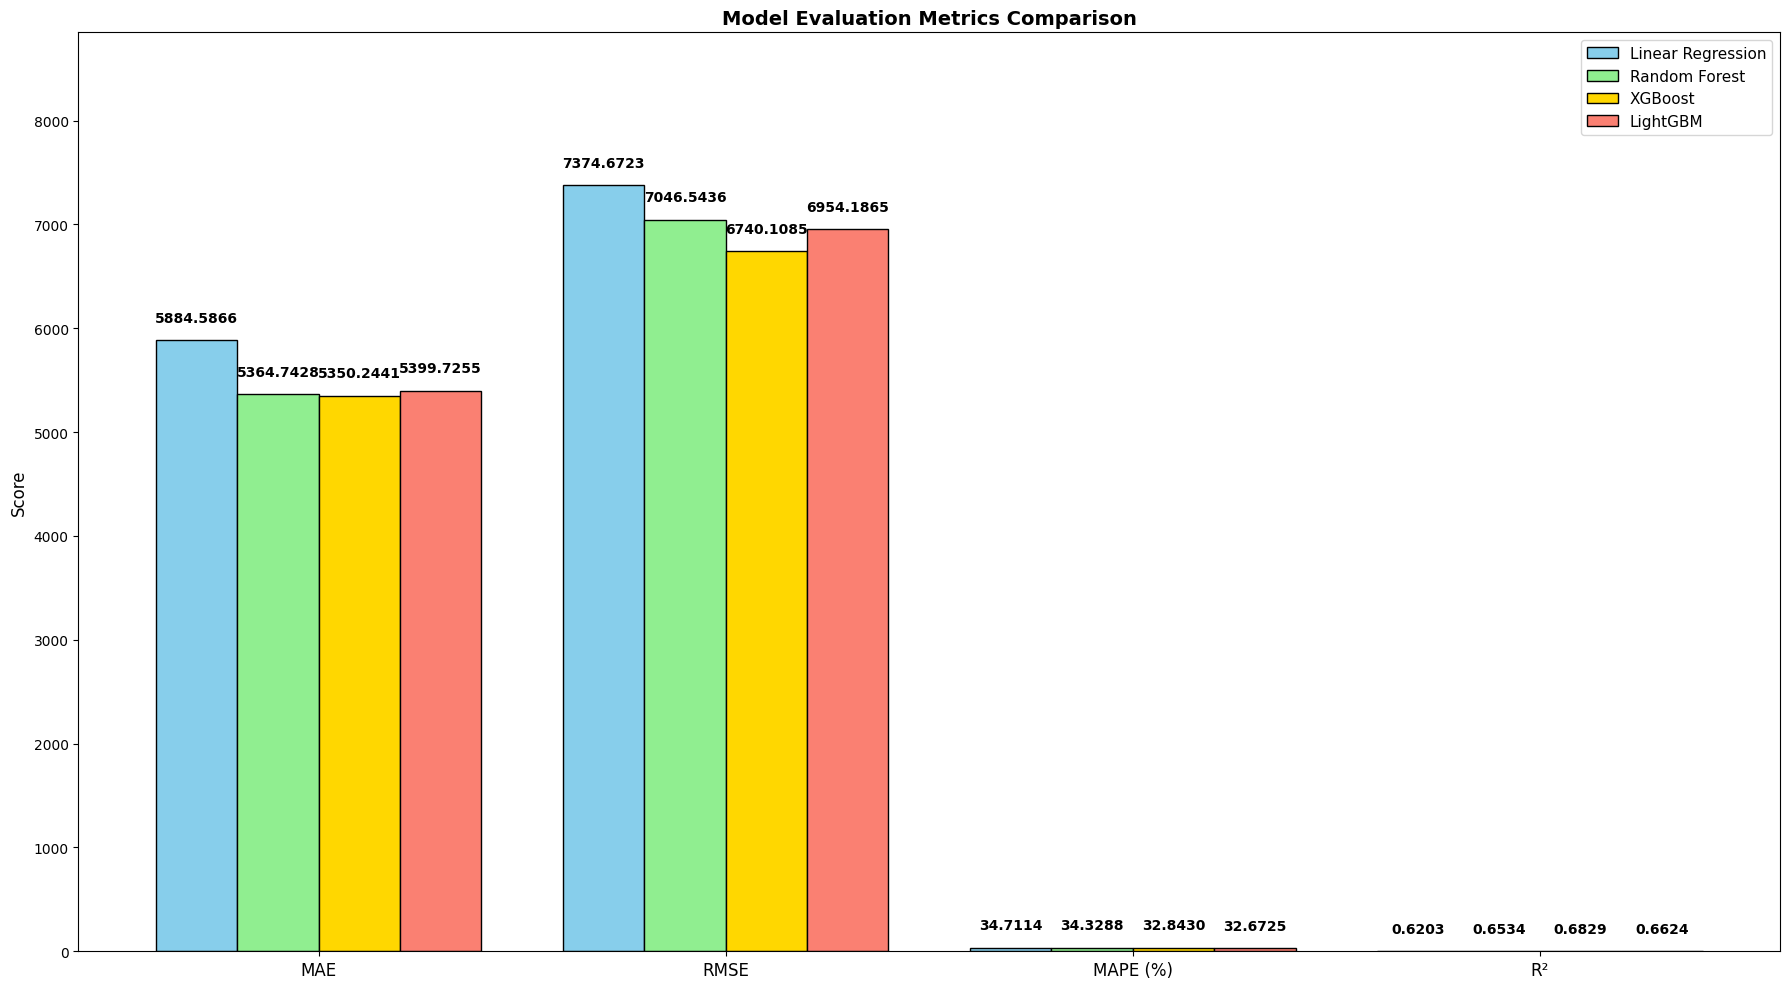

In [382]:
metrics = ["MAE", "RMSE", "MAPE (%)", "R²"]
lr_scores   = [lr_mae, lr_rmse, lr_mape, lr_r2]
rf_scores   = [best_rf_mae, best_rf_rmse, best_rf_mape, best_rf_r2]
xgb_scores  = [best_xgb_mae, best_xgb_rmse, best_xgb_mape, best_xgb_r2]
lgbm_scores = [best_lgbm_mae, best_lgbm_rmse, best_lgbm_mape, best_lgbm_r2]

x = np.arange(len(metrics))
width = 0.2  # slightly narrower bars

plt.figure(figsize=(18, 10))

# Plot bars
bars1 = plt.bar(x - 1.5*width, lr_scores,   width, label="Linear Regression", color="skyblue", edgecolor='black')
bars2 = plt.bar(x - 0.5*width, rf_scores,   width, label="Random Forest",     color="lightgreen", edgecolor='black')
bars3 = plt.bar(x + 0.5*width, xgb_scores,  width, label="XGBoost",           color="gold", edgecolor='black')
bars4 = plt.bar(x + 1.5*width, lgbm_scores, width, label="LightGBM",          color="salmon", edgecolor='black')

# Formatting
plt.ylim(0, max(max(lr_scores), max(rf_scores), max(xgb_scores), max(lgbm_scores)) * 1.2)
plt.xticks(x, metrics, fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.title("Model Evaluation Metrics Comparison", fontsize=14, fontweight="bold")
plt.legend(fontsize=11)

# Add value labels
all_bars = [bars1, bars2, bars3, bars4]
for bars in all_bars:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.02*plt.ylim()[1],
                 f"{height:.4f}", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

Best Model Predict Graph

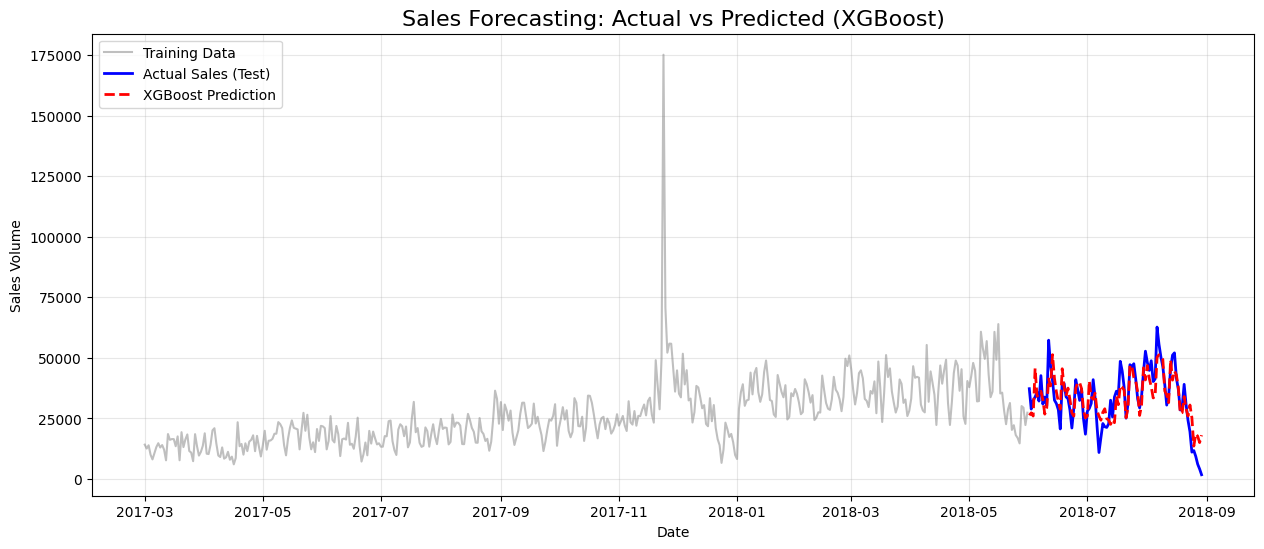

In [383]:
xgb_pred_series = pd.Series(best_xgb_y_pred, index=y_test.index)

# --- 2. Plotting ---
plt.figure(figsize=(15, 6))

# Plot 1: Training Data (The Past) - Grey/Blue
plt.plot(y_train, label='Training Data', color='grey', alpha=0.5)

# Plot 2: Actual Test Data (The Ground Truth) - Blue
plt.plot(y_test, label='Actual Sales (Test)', color='blue', linewidth=2)

# Plot 3: Model Predictions - Red/Orange
plt.plot(xgb_pred_series, label='XGBoost Prediction', color='red', linestyle='--', linewidth=2)

# Styling
plt.title('Sales Forecasting: Actual vs Predicted (XGBoost)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Sales Volume')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

plt.show()

In [385]:
history_window = 60 
future_days = 30
last_date = sales_forecast_data.index.max()

future_df = sales_forecast_data.iloc[-history_window:].copy()

print(f"Starting Recursive Forecast from {last_date}...")

for i in range(1, future_days + 1):
    next_date = last_date + pd.Timedelta(days=i)
    
    new_row = pd.DataFrame(index=[next_date], columns=future_df.columns)
    future_df = pd.concat([future_df, new_row])
    
    future_df = create_features(future_df)
    
    X_next = future_df.iloc[[-1]][features] 
    
    pred_value = final_model.predict(X_next)[0]
    
    future_df.loc[next_date, 'sales'] = pred_value
    
    if future_df.loc[next_date, 'sales'] < 0:
        future_df.loc[next_date, 'sales'] = 0

print("Forecasting Complete.")

# 3. Extract just the future part
forecast_results = future_df.iloc[-future_days:][['sales']]
forecast_results.columns = ['Predicted_Sales']

print(forecast_results.head())

Starting Recursive Forecast from 2018-08-29 00:00:00...
Forecasting Complete.
            Predicted_Sales
2018-08-30     13224.572266
2018-08-31     16100.920898
2018-09-01     17017.544922
2018-09-02     16742.501953
2018-09-03     20689.603516


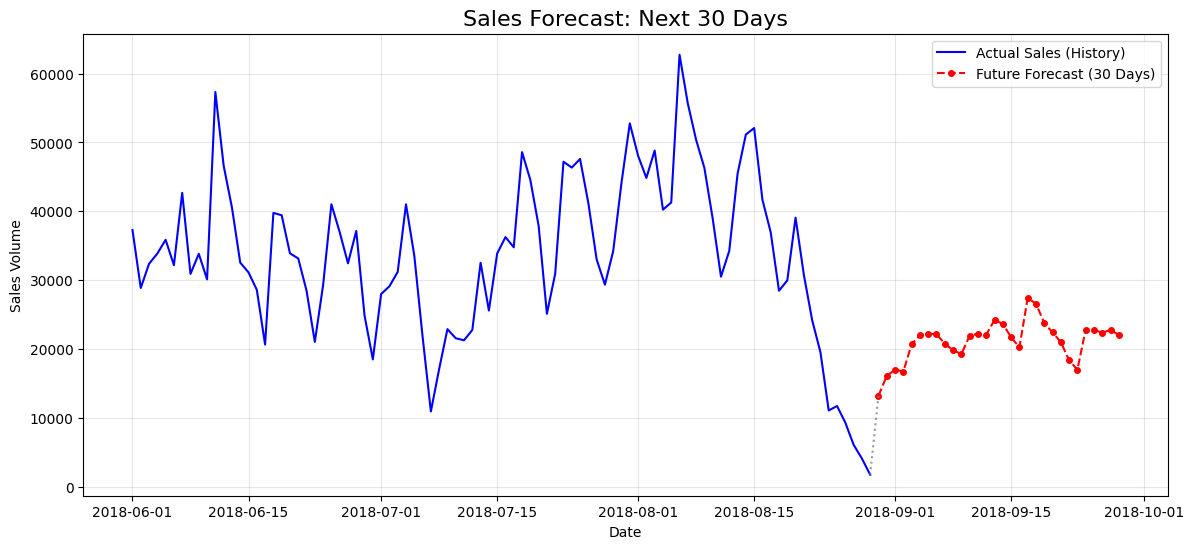

In [ ]:
plt.figure(figsize=(14, 6))

# 1. Plot Actual Data (Blue)
plt.plot(test.index, y_test, label='Actual Sales (History)', color='blue')

# 2. Plot Future Forecast (Red)
plt.plot(forecast_results.index, forecast_results['Predicted_Sales'], 
         label='Future Forecast (30 Days)', color='red', linestyle='--', marker='o', markersize=4)

# --- 3. THE CONNECTOR (The Bridge) ---
# Get the last point of history
last_hist_date = test.index[-1]
last_hist_value = y_test.iloc[-1]

# Get the first point of forecast
first_pred_date = forecast_results.index[0]
first_pred_value = forecast_results['Predicted_Sales'].iloc[0]

# Draw a grey dotted line between them
plt.plot([last_hist_date, first_pred_date], 
         [last_hist_value, first_pred_value], 
         color='grey', linestyle=':', alpha=0.8)

plt.title('Sales Forecast: Next 30 Days', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Sales Volume')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Deploy best model**

In [389]:
joblib.dump(final_model, "sales_forecasting_amount_model.pkl")
print("✅ Model saved as sales_forecasting_amount_model.pkl")

✅ Model saved as sales_forecasting_amount_model.pkl
